In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
from handcalcs import *
from handcalcs import render
import handcalcs

In [3]:
def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]


In [4]:
# Initialization 
bl= '#1520c0' # blue 
rd= '#C62828' # red
fig_counter=1

In [5]:
# CONFIGURATIONS
#help(handcalcs.set_option)
handcalcs.set_option("latex_block_start", "$")
handcalcs.set_option("latex_block_end", "$")
handcalcs.set_option("math_environment_end", "aligned")
handcalcs.set_option("use_scientific_notation",True)

In [6]:
from figModel import *

# Mosfet gate driver and double pulse tests

## Primary driver

In [7]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="Schem.png", 
                         caption1="Reminder of the primary gate driver sub-schematic", 
                         first_part_path="./figs/", 
                         width=19)

### Driver HW dead time


<u> Oscilloscope:</u> <br> 
* **CH1** : INA
* **CH2** : INB
* **CH3** : OUTA
* **CH4** : OUTB

<u> Driver:</u> <br> 
**ucc21520Q**
<br>
<br> <u> Programmed dead time </u><br>
RT = 11.5k, so dead time = 115ns

In [8]:
fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="s1.png", 
                               caption1="Zoom out to see 2 periods, 100khz", 
                               img2="s2.png", 
                               caption2="Zoom in around the dead time: DT=126ns", 
                               first_part_path="01_driver_no_sw_dead_time/")



In [9]:
#s3.png
fig_counter=show_figure_pair_with_captions(fig_counter, 
                               img1="s1.png", 
                               caption1="Zoom out to see 2 periods, 100khz", 
                               img2="s3.png", 
                               caption2="Zoom in around the dead time: DT=116ns", 
                               first_part_path="01_driver_no_sw_dead_time/")



In [10]:
%%render 2
DT_Prog = 115 # ns
DT_Meas = 116 # ns
Error =  100*(DT_Meas-DT_Prog)/DT_Prog # \%

<IPython.core.display.Latex object>

### Bootstrap circuit

**One pulse**

In [36]:
%%render 
V12=12# V
Vd= 0.7 #V
Rboot =2.15
Iboot = (V12-Vd)/Rboot

<IPython.core.display.Latex object>

In [13]:

fig_counter=One_figure_with_captions(fig_counter, 
                         img1="2025-12-01_16-48-34-151.png", 
                         caption1="Bootstrap circuit measurement with 10us pulse width", 
                         first_part_path="./04_boostramp_capa/OnePulse10us/", 
                         width=12)

Oscilloscope:<br> 
* **CH1** : bootstrap capacitor voltage
* **CH2** : bootstrap diode current
* **CH4** : Vgs low side MOSFET

In [31]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="boot2.png", 
                         caption1="Quick simulation of the bootstrap circuit with 10us pulse width", 
                         first_part_path="./04_boostramp_capa/sim/", 
                         width=15)

In [24]:
#file = "./04_boostramp_capa/OnePulse10us/2025-12-01_16-48-34-151.csv"
#dfb = pd.read_csv(file)

**PWM mode**

In [38]:
file = "2025-12-01_17-40-57-756.csv"
folder = "./04_boostramp_capa/PWM100kHz/"

In [41]:

fig_counter=One_figure_with_captions(fig_counter, 
                         img1=file.replace(".csv",".png"), 
                         caption1="Bootstrap circuit measurement with PWM 100kHz 50% duty cycle", 
                         first_part_path=folder, 
                         width=12)

In [44]:
fig_counter=One_figure_with_captions(fig_counter, 
                         img1="boot3.png", 
                         caption1="Quick simulation of the bootstrap circuit 100kHz 50% duty cycle", 
                         first_part_path="./04_boostramp_capa/sim/", 
                         width=15)

## Secondary driver

##

In [ ]:
1

### Double pulse test

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [47]:
df = pd.read_csv(r"./02_double_pulse/366.5V_V3/2025-11-29_13-10-08-387.csv")
vds = df.CH1.values*100  # x100 probe
iD =  df.CH2.values # x100 probe

vds_thre= vds.mean()
iD_thre= iD.mean()

In [49]:
df = pd.read_csv("./02_double_pulse/366.5V_V3/2025-11-29_15-40-48-127.csv")
#df.head()

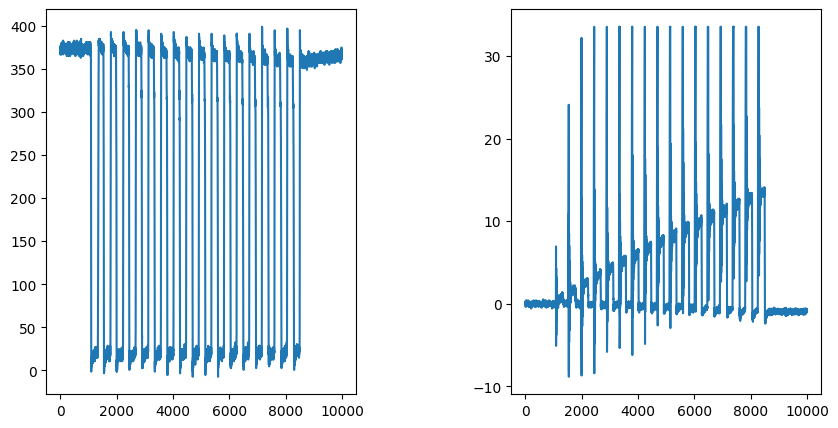

In [50]:
Ts = df.Ts.values[0]
vds = df.CH1.values*100 -vds_thre # x100 probe
iD =  df.CH2.values-iD_thre # x100 probe
iD = iD -iD[:500].mean()
#diD =  df.CH2.values # x100 probe
#diD = diD -diD[:500].mean()

#vgs = df.CH4.values
#vgs = vgs-vgs[:500].mean()


fig, axs = plt.subplots(1,2, figsize=(10,5)
, gridspec_kw={'wspace':0.5#, 'hspace': 1.0
              })
axs[0].plot(vds)
axs[1].plot(iD)

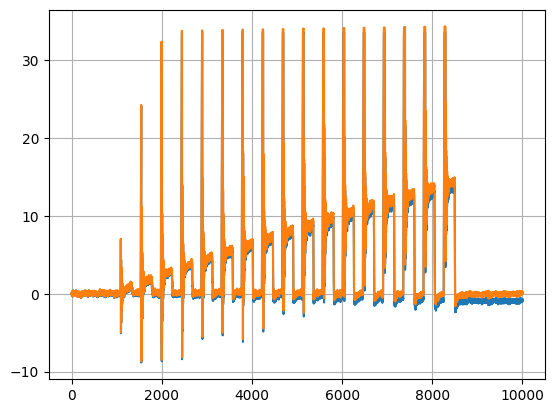

In [51]:
plt.plot(iD)
#k= 7e-5
#iD2= iD + np.arange(0,len(iD))*k
#iD2[:100].mean(), iD2[-100:].mean()
def ID2_find(iD): 
    a = np.arange(len(iD))
    k = (iD[-100:].mean() - iD[:100].mean()) / (a[:100].mean() - a[-100:].mean())
    iD2 = iD + a * k
    return k, iD2 
k, iD2 = ID2_find(iD)

plt.plot(iD2)
plt.grid()
plt.show()
# Primary y-axis
p = vds*iD2
p = p-p[:500].mean()
E =np.cumsum(p)*Ts
#plt.plot(t, p, color='C2')
#plt.show()
#plt.plot( E)


35


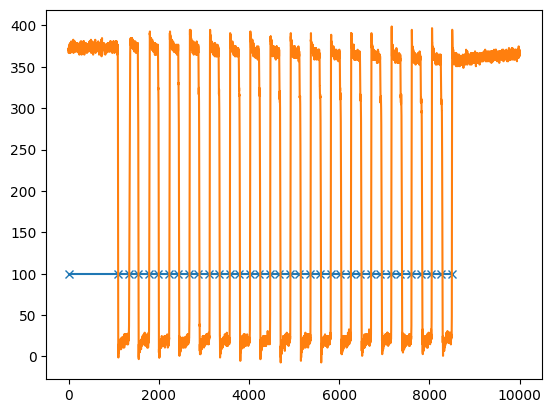

In [27]:
from math import *
arg=[0]
for i in range(10, len(vds)-10):
    if abs(vds[i+3]-vds[i-3])>20:
        if i-arg[-1]>100:
            arg.append(i) 
print(len(arg))
plt.plot(arg, len(arg)*[100], marker="x")
plt.plot(vds)

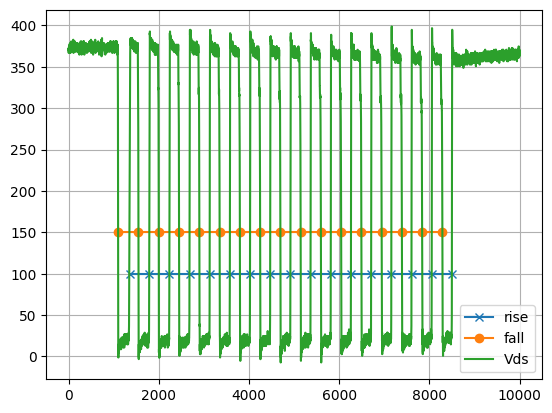

In [28]:
def trigger (sig , thresh= None, transition= "rise", marginI = 20):
    arr=[0]
    if thresh is None: 
        thresh = (sig.max()+sig.min())/2
    for i in range(1, len(sig)):
        if transition =="rise":
            if sig[i-1] <thresh and sig[i] >= thresh and i > arr[-1]+marginI:
                arr.append(i)
        elif sig[i-1] >thresh and sig[i] <= thresh and i > arr[-1]+marginI:
            arr.append(i)
    return arr[1:]
idx_rise = trigger (vds, transition= "rise")
idx_fall= trigger (vds, transition= "fall")
plt.plot(idx_rise, len(idx_rise)*[100], marker="x", label = "rise")
plt.plot(idx_fall, len(idx_fall)*[150], marker="o", label = "fall")
plt.plot(vds, label = "Vds")
plt.legend()
plt.grid()

In [29]:
Ts= df.Ts.iloc[0]

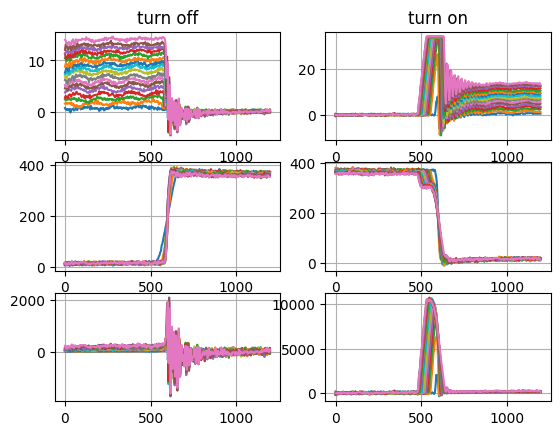

In [63]:
def EONEOFF (plot = True, pltshow = True): 
    idx_rise = trigger (vds, transition= "rise")
    idx_fall= trigger (vds, transition= "fall")
    if plot : 
        fig , axs= plt.subplots(3,2)
    di=150
    Eon={}
    Eoff={}
    deltaV={}
    k, iD2 = ID2_find(iD)
    #print(Ts)
    for i in idx_rise: 
        ### off
        
        
        I1 = iD2[i-di-10:i-di].mean()
        
    
    
        I0 = iD2[i+di-50:i+di].mean()
        V0 = iD2[i-di:i-di+50].mean()
        V0=0
        p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        #print(i, di, i-di,i+di)
  
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2= p
        E= np.sum(p2)*Ts*1e6
    
        Eoff[I1]=E

        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[2][0].plot(t,y)
            y=vds[i-di:i+di]
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[1][0].plot(t,y)
            axs[0][0].set_title("turn off")
            y = iD2[i-di:i+di]-I0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[0][0].plot(t,y)
        deltaV[I1]= vds[i-di:i+di].max()-vds[i-di:i+di][-20:].mean()
    for i in idx_fall: 
        I1 = iD2[i+10:i+di*2+10].mean()
        I0 = iD2[i-di:i-di+50].mean()
    
        V0 = iD2[i+di-50:i+di].mean()
        V0=0
    
        p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2 =p
        E= np.sum(p2)*Ts*1e6
        
        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[2][1].plot(t,y)
            y = vds[i-di:i+di]
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[1][1].plot(t,y)
            axs[0][1].set_title("turn on")
            y=iD2[i-di:i+di]-I0
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            axs[0][1].plot(t,y)
        Eon[I1]=E
    if plot : 
        for ax in axs .flatten(): 
            ax.grid()
    if pltshow:
        plt.show()
    else:
        plt.close(fig)   # <-- prevents showing but keeps fig so user can save it
    return Eon , Eoff, deltaV, fig
Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = True)


(<Figure size 1000x500 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

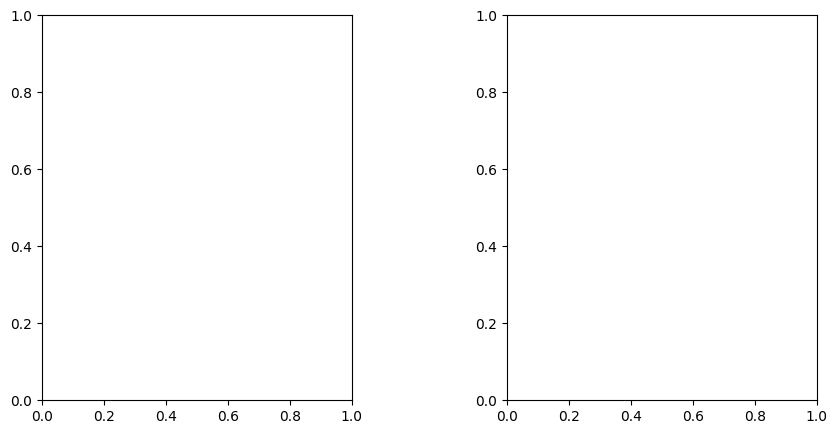

4e-09
Imean = 0.58A, Coss=0.18nF
Imean = 0.72A, Coss=0.13nF
Imean = 1.42A, Coss=0.17nF
Imean = 1.82A, Coss=0.17nF
Imean = 2.27A, Coss=0.19nF
Imean = 2.65A, Coss=0.20nF
Imean = 3.19A, Coss=0.24nF
Imean = 3.31A, Coss=0.21nF
Imean = 3.75A, Coss=0.27nF
Imean = 4.13A, Coss=0.30nF
Imean = 4.27A, Coss=0.35nF
Imean = 4.45A, Coss=0.37nF
Imean = 4.91A, Coss=0.42nF
Imean = 5.21A, Coss=0.45nF
Imean = 5.55A, Coss=0.43nF
Imean = 5.82A, Coss=0.46nF
Imean = 5.88A, Coss=0.49nF


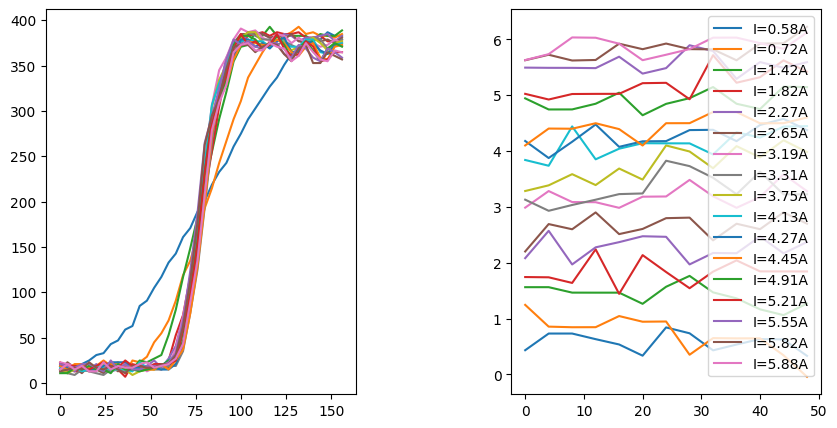

In [103]:
plot = True
pltshow = True
fig, axs = plt.subplots(1,2, figsize=(10,5), gridspec_kw={'wspace':0.5})
a=[]
if 1: 
    idx_rise = trigger (vds, transition= "rise")
    idx_fall= trigger (vds, transition= "fall")

    di=150
    Eon={}
    Eoff={}
    deltaV={}
    k, iD2 = ID2_find(iD)
    print(Ts)
    for i in idx_rise: 
        ### off
        
        
        I1 = iD2[i-di-10:i-di].mean()
        
    
    
        I0 = iD2[i+di-50:i+di].mean()
        V0 = iD2[i-di:i-di+50].mean()
        V0=0
        p=(vds[i-di:i+di]-V0)*(iD2[i-di:i+di]-I0)
        #print(i, di, i-di,i+di)
  
        indx = np.where(p>p.max()/2)[0]
        p2= p[indx[0]-20:indx[-1]+20]
        p2= p
        E= np.sum(p2)*Ts*1e6
    
        Eoff[I1]=E

        if plot :
            y = p
            t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[2][0].plot(t,y)
            di=20
            y=vds[i-di:i+di]
            t= np.arange(0,len(y)*Ts, Ts)*1e9

            mask = (y > (vds.min()+50)) & (y < (vds.max()-50))
            Y= y[mask]
            X = t[mask]
            dvdt= (Y[0 ]-Y[-1])/(X[0 ]-X[-1]) # i = c dv/dt

            axs[0].plot(t,y)
            #axs[0][0].set_title("turn off")
            y = iD2[i-di:i-7]-I0
            axs[1].plot(t[:len(y)],y, label = f"I={y.mean():.2f}A")
            Imean = y.mean()
            Coss= Imean/dvdt
            print(f"Imean = {Imean:.2f}A, Coss={Coss:.2f}nF")
            a.append(y.mean()   )
            #t= np.arange(0,len(y)*Ts, Ts)*1e9
            #axs[0][0].plot(t,y)
        deltaV[I1]= vds[i-di:i+di].max()-vds[i-di:i+di][-20:].mean()

axs[1].legend()
plt.show()

In [ ]:
y=vds[i-di:i+di]
mask = (y > (vds.min()+50)) & (y < (vds.max()-50))
Y= y[mask]
X = t[mask]
dvdt= (Y[0 ]-Y[-1])/(X[0 ]-X[-1]) # i = c dv/dt
print(Coss_eq)


11.904947916666666


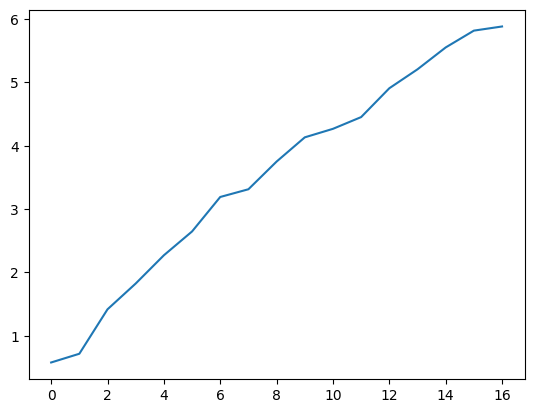

In [84]:
plt.plot(a)

In [65]:
Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = False)
fig.savefig("figs/test.png")

<Axes: >

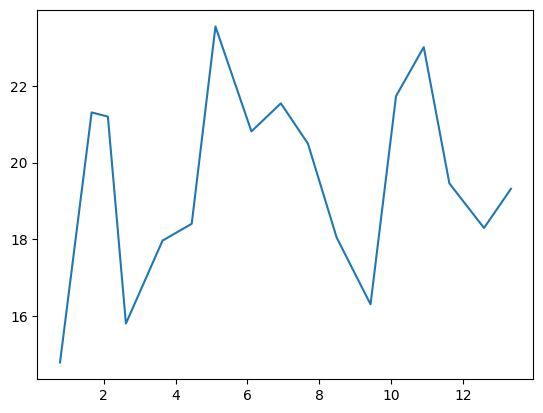

In [66]:
pd.Series(deltaV).plot()

In [67]:
# without dead time 
#E0= Vmos*I*T
# with dead time 
#E1= Vmos*I*(T-2*dead)+VF*I*2dead=Vmos*I*T -2*Vmos*I*dead+VF*I*2dead
#dE/E0= 2*(dead/T)*(VF-Vmos)/Vmos
Vmos = 0.2
T=10e3 # ns
VF=1
for dead in (50,100,150,200,300):
    print("# dead ns", dead, "dE/E0 % = ",100*2*(dead/T)*(VF-Vmos)/Vmos)
# dead ns 50 dE/E0 % =  0.04
# dead ns 100 dE/E0 % =  0.08
# dead ns 150 dE/E0 % =  0.12
# dead ns 200 dE/E0 % =  0.16
# dead ns 300 dE/E0 % =  0.24

# dead ns 50 dE/E0 % =  4.0
# dead ns 100 dE/E0 % =  8.0
# dead ns 150 dE/E0 % =  12.000000000000002
# dead ns 200 dE/E0 % =  16.0
# dead ns 300 dE/E0 % =  24.000000000000004


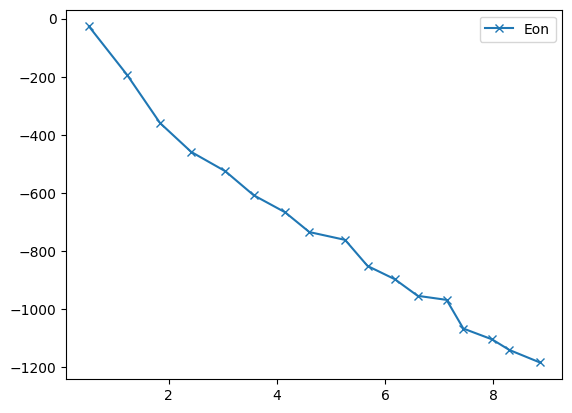

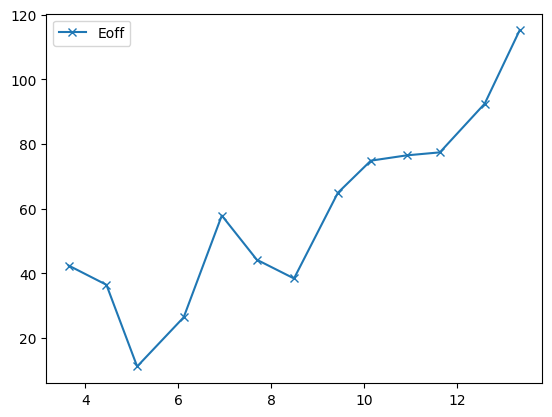

In [68]:
(-pd.Series(Eon)).plot(label = "Eon",marker="x")
plt.legend()
plt.show()
s=pd.Series(Eoff)
s=s[s.index>3]
s.plot(label = "Eoff",marker="x")
plt.legend()

# End

In [69]:
l = """10 ohm 
2025-11-29_15-40-48-127
5 ohm
2025-11-29_15-41-49-332
3 ohm
2025-11-29_15-42-24-226
3 ohm V2
2025-11-29_15-51-14-933
3//5=1.87 ohm 
2025-11-29_16-23-05-938
10//3 =2.3 ohm 
2025-11-29_16-25-13-741""".replace(" ", "").split("\n")
names = l[1::2]
labels=l[0::2]
names = [r"./02_double_pulse/366.5V_V3/" + x for x in names]
#print(names), print(labels)

In [70]:
#list={}
dic  = {}
for i in range(len(names)):
    data ={}
    path  = names[i]+".csv"
    label = labels[i]
    #print(path, label)
    df = pd.read_csv(path)
    Ts = df.Ts.values[0]
    vds = df.CH1.values*100 -vds_thre # x100 probe
    iD =  df.CH2.values-iD_thre # x100 probe
    iD = iD -iD[:500].mean()
    
    

    Eon , Eoff, deltaV , fig= EONEOFF (plot = True, pltshow = False)
    fig.savefig(f"figs/{label.replace("/", "_")}.png")
  
      
        
    #plt.show()  
    data["Eon"]=Eon
    #(-pd.Series(Eon)).plot(label = "Eon",marker="x")
    #s.plot(label = "Eoff",marker="x")
    data["Eoff"]= Eoff
    data["deltaV"]= deltaV
    #plt.legend()
    #plt.show()
    dic[label]= data

In [57]:
#dic

In [58]:
dic.keys()

dict_keys(['10ohm', '5ohm', '3ohm', '3ohmV2', '3//5=1.87ohm', '10//3=2.3ohm'])

In [59]:
dic['10ohm'].keys()

dict_keys(['Eon', 'Eoff', 'deltaV'])

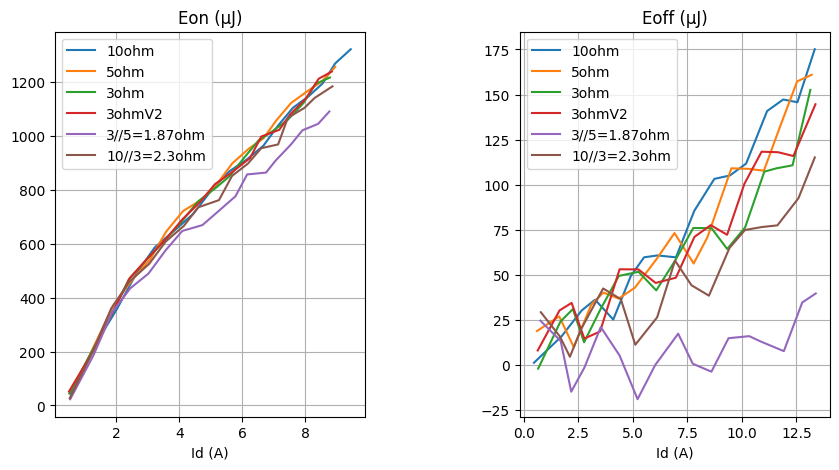

In [71]:
fig, axs = plt.subplots(1,2, figsize=(10,5)
, gridspec_kw={'wspace':0.5#, 'hspace': 1.0
              })
for kk, v in dic.items():
    Eon = v["Eon"]
    #Eon = Eon[Eon.index>1]
    Splot = pd.Series(Eon)

    Splot.plot(ax = axs[0], label = kk)
    Eoff = v["Eoff"]
    #Eon = Eon[Eon.index>1]
    Splot = pd.Series(Eoff)
    
    Splot.plot(ax = axs[1], label = kk)
axs[0].set_title("Eon (µJ)")
axs[1].set_title("Eoff (µJ)")
axs[0].set_xlabel("Id (A)")
axs[1].set_xlabel("Id (A)")
axs[0].grid()
axs[1].grid()
axs[0].legend()
axs[1].legend()